In [ ]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Load Data

In [3]:
df = pd.read_csv("food_delivery_pattern_analysis_1000_rows.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (1000, 13)


,transaction_item_id,order_id,customer_id,restaurant_name,meal_name,category,rating,review_text,sentiment_label,delivery_time,food_preparation_time,cost_of_the_order,order_date
0,TI000001,ORD00001,C0063,Pizza Palace,Margherita Pizza,Main,5.0,Perfect meal for a cozy evening at home.,positive,28.0,33.0,11.18,2024-04-24
1,TI000002,ORD00001,C0063,Pizza Palace,Pepsi,Drink,5.0,Perfect meal for a cozy evening at home.,positive,28.0,33.0,11.18,2024-04-24
2,TI000003,ORD00002,C0008,Pizza Palace,Pepperoni Pizza,Main,NaN,"Cold food and extremely late delivery, very un...",negative,33.0,17.0,17.98,2024-02-17
3,TI000004,ORD00002,C0008,Pizza Palace,Caesar Salad,Side,1.0,"Cold food and extremely late delivery, very un...",negative,33.0,17.0,17.98,2024-02-17
4,TI000005,ORD00002,C0008,Pizza Palace,Pepsi,Drink,1.0,NaN,negative,33.0,17.0,17.98,2024-02-17


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_item_id    1000 non-null   object 
 1   order_id               1000 non-null   object 
 2   customer_id            1000 non-null   object 
 3   restaurant_name        1000 non-null   object 
 4   meal_name              1000 non-null   object 
 5   category               1000 non-null   object 
 6   rating                 951 non-null    float64
 7   review_text            942 non-null    object 
 8   sentiment_label        938 non-null    object 
 9   delivery_time          921 non-null    float64
 10  food_preparation_time  941 non-null    float64
 11  cost_of_the_order      1000 non-null   float64
 12  order_date             1000 non-null   object 
dtypes: float64(4), object(9)
memory usage: 101.7+ KB


In [5]:
df.values

array([['TI000001', 'ORD00001', 'C0063', ..., 33.0, 11.18, '2024-04-24'],
       ['TI000002', 'ORD00001', 'C0063', ..., 33.0, 11.18, '2024-04-24'],
       ['TI000003', 'ORD00002', 'C0008', ..., 17.0, 17.98, '2024-02-17'],
       ...,
       ['TI000277', 'ORD00105', 'C0137', ..., 30.0, 19.91, '2024-07-13'],
       ['TI000278', 'ORD00106', 'C0059', ..., 13.0, 11.0, '2024-02-16'],
       ['TI000279', 'ORD00106', 'C0059', ..., 13.0, 11.0, '2024-02-16']],
      dtype=object)

##  Cleaning and Preprocessing

In [6]:
clean_df = df.copy()

text_cols = [
    "transaction_item_id", "order_id", "customer_id", "restaurant_name",
    "meal_name", "category", "review_text", "sentiment_label"
]

for col in text_cols:
    clean_df[col] = clean_df[col].astype("string").str.strip()

clean_df["order_date"] = pd.to_datetime(clean_df["order_date"], errors="coerce")

num_cols = ["rating", "delivery_time", "food_preparation_time", "cost_of_the_order"]
for col in num_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

clean_df["review_text"] = clean_df["review_text"].fillna("No review provided")
clean_df["sentiment_label"] = clean_df["sentiment_label"].fillna("unknown").str.lower()
clean_df["category"] = clean_df["category"].str.title()


clean_df = clean_df.drop_duplicates()

print("Rows after cleaning:", len(clean_df))
print("Unique orders:", clean_df["order_id"].nunique())
print("Remaining duplicates:", clean_df.duplicated().sum())

display(clean_df.head())

Rows after cleaning: 721
Unique orders: 270
Remaining duplicates: 0


,transaction_item_id,order_id,customer_id,restaurant_name,meal_name,category,rating,review_text,sentiment_label,delivery_time,food_preparation_time,cost_of_the_order,order_date
0,TI000001,ORD00001,C0063,Pizza Palace,Margherita Pizza,Main,5.0,Perfect meal for a cozy evening at home.,positive,28.0,33.0,11.18,2024-04-24
1,TI000002,ORD00001,C0063,Pizza Palace,Pepsi,Drink,5.0,Perfect meal for a cozy evening at home.,positive,28.0,33.0,11.18,2024-04-24
2,TI000003,ORD00002,C0008,Pizza Palace,Pepperoni Pizza,Main,4.0,"Cold food and extremely late delivery, very un...",negative,33.0,17.0,17.98,2024-02-17
3,TI000004,ORD00002,C0008,Pizza Palace,Caesar Salad,Side,1.0,"Cold food and extremely late delivery, very un...",negative,33.0,17.0,17.98,2024-02-17
4,TI000005,ORD00002,C0008,Pizza Palace,Pepsi,Drink,1.0,No review provided,negative,33.0,17.0,17.98,2024-02-17


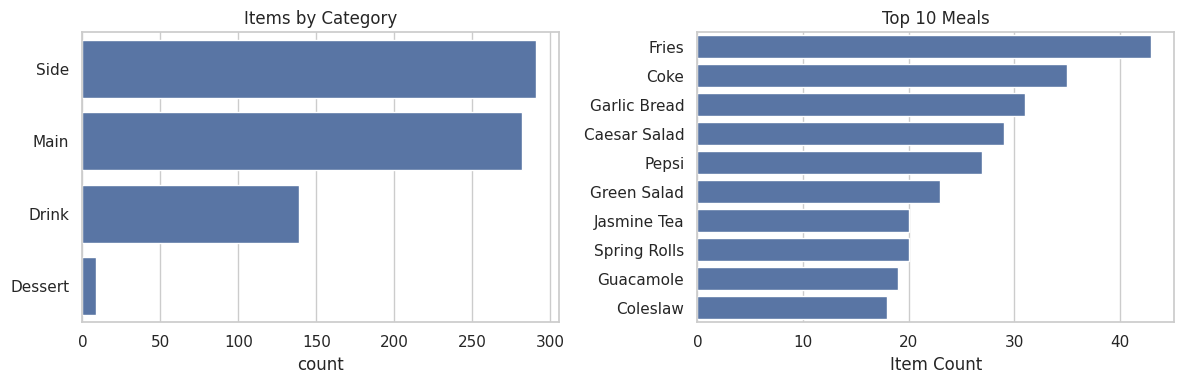

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=clean_df, y="category", order=clean_df["category"].value_counts().index, ax=axes[0])
axes[0].set_title("Items by Category")
axes[0].set_ylabel("")

top_meals = clean_df["meal_name"].value_counts().head(10)
sns.barplot(x=top_meals.values, y=top_meals.index, ax=axes[1])
axes[1].set_title("Top 10 Meals")
axes[1].set_xlabel("Item Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Transaction Building


In [8]:
transactions_df = (
    clean_df.groupby("order_id")["meal_name"]
    .apply(lambda meals: sorted(set(meals.dropna())))
    .reset_index(name="meals")
)

transactions_df["meal_count"] = transactions_df["meals"].apply(len)

transactions_df = transactions_df[transactions_df["meal_count"] >= 2].copy()

transactions_df["transaction"] = transactions_df["meals"].apply(", ".join)

transactions = transactions_df["meals"].tolist()

encoder = TransactionEncoder()
one_hot_array = encoder.fit(transactions).transform(transactions)

one_hot = pd.DataFrame(
    one_hot_array,
    columns=encoder.columns_
)

one_hot.insert(0, "order_id", transactions_df["order_id"].values)

print("Transactions:", len(transactions_df))
print("Unique meals:", one_hot.shape[1] - 1)

display(transactions_df.head())
display(one_hot.head())

Transactions: 270
Unique meals: 46


,order_id,meals,meal_count,transaction
0,ORD00001,"[Margherita Pizza, Pepsi]",2,"Margherita Pizza, Pepsi"
1,ORD00002,"[Caesar Salad, Pepperoni Pizza, Pepsi]",3,"Caesar Salad, Pepperoni Pizza, Pepsi"
2,ORD00003,"[Dumpling, Pad Thai]",2,"Dumpling, Pad Thai"
3,ORD00004,"[Edamame, Miso Soup, Tuna Roll]",3,"Edamame, Miso Soup, Tuna Roll"
4,ORD00005,"[Chicken Wrap, Fries, Lemonade]",3,"Chicken Wrap, Fries, Lemonade"


,order_id,Avocado Toast,BBQ Chicken Pizza,Beef Taco,Beef Wrap,Burger,Caesar Salad,Chicken Strips,Chicken Taco,Chicken Wrap,...,Ramen,Salmon Sushi,Shrimp Tempura,Smoothie,Spaghetti Carbonara,Spring Rolls,Tiramisu,Tuna Roll,Udon,Veggie Burger
0,ORD00001,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,ORD00002,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,ORD00003,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,ORD00004,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,ORD00005,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## Apriori algorithm

## Overview

The **Apriori algorithm** is a classic algorithm used in **Association Rule Learning** to discover frequent itemsets and generate association rules from transactional datasets.

In this project, it is applied to the **Food_delivery_pattern_analysis** dataset to discover meal combinations that are frequently ordered together.

---

## Core Idea (Apriori Principle)

> If an itemset is frequent, then all of its subsets must also be frequent.

This property reduces the search space by pruning non-frequent itemsets early.

---

## How Apriori Works (Steps)

1. **Set Minimum Support**
   - Define a threshold to determine which itemsets are considered frequent.

2. **Generate Frequent 1-Itemsets**
   - Calculate support for each individual meal.
   - Remove meals below `min_support`.

3. **Generate Candidate k-Itemsets**
   - Combine frequent `(k-1)` itemsets to form larger itemsets.

4. **Prune Non-Frequent Itemsets**
   - Remove itemsets whose support is less than `min_support`.

5. **Repeat**
   - Continue until no new frequent itemsets are found.

6. **Generate Association Rules**
   - From frequent itemsets, generate rules using confidence and lift.

---

## Important Metrics

### 1. Support

Measures how frequently an itemset appears in the dataset.

$$
Support(A) = \frac{\text{Number of transactions containing A}}{\text{Total transactions}}
$$

---

### 2. Confidence

Measures how often **B** occurs given that **A** has occurred.

$$
Confidence(A \rightarrow B) = \frac{Support(A \cap B)}{Support(A)}
$$

---

### 3. Lift

Measures how much more likely **B** is to occur with **A** compared to random chance.

$$
Lift(A \rightarrow B) = \frac{Confidence(A \rightarrow B)}{Support(B)}
$$

- **Lift > 1** → Positive association
- **Lift = 1** → No association
- **Lift < 1** → Negative association

---

## Key Parameters in Apriori (mlxtend)

### `min_support`

- Minimum support threshold.
- Filters out infrequent itemsets.
- Example: `min_support = 0.03`

### `max_len`

- Maximum length of itemsets.
- Example: `max_len = 3`

---

## Parameters in Association Rules

### `metric`

- Metric used to filter rules.
- Options: `"confidence"`, `"lift"`, `"support"`

---

### `min_threshold`

- Minimum value for the selected metric.
- Example: `min_threshold = 0.25`

---

## Advantages

- Easy to understand and implement
- Strong theoretical foundation
- Works well on small to medium datasets

---

## Limitations

- Computationally expensive for large datasets
- Generates many candidate itemsets
- Not suitable for high-dimensional big data
- Scans the dataset many times to calculate **support**

---

## Faster Alternative

For large datasets, **FP-Growth** can be used because it avoids candidate generation and is more efficient.

In [9]:
min_support = 0.03
min_confidence = 0.25

basket = one_hot.drop(columns=["order_id"])

frequent_itemsets = apriori(
    basket,
    min_support=min_support,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=min_confidence
)

rules = rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

rules["antecedents"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequents"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules["rule"] = rules["antecedents"] + " -> " + rules["consequents"]

best_meal_combinations = rules[
    ["rule", "support", "confidence", "lift"]
].copy()

best_meal_combinations[["support", "confidence", "lift"]] = (
    best_meal_combinations[["support", "confidence", "lift"]].round(4)
)


frequent_itemsets.to_csv( "frequent_itemsets.csv", index=False)
best_meal_combinations.to_csv( "best_meal_combinations.csv", index=False)

print("Files saved successfully")

display(best_meal_combinations.head(15))

Files saved successfully


,rule,support,confidence,lift
0,Penne Arrabiata -> Tiramisu,0.0333,0.6429,19.2857
1,Tiramisu -> Penne Arrabiata,0.0333,1.0000,19.2857
2,Tuna Roll -> Edamame,0.0481,1.0000,16.8750
3,"Coleslaw, Lemonade -> Chicken Wrap",0.0407,1.0000,16.8750
4,"Green Salad, Shrimp Tempura -> Salmon Sushi",0.0407,1.0000,16.8750
5,Edamame -> Tuna Roll,0.0481,0.8125,16.8750
6,"Chicken Wrap -> Coleslaw, Lemonade",0.0407,0.6875,16.8750
7,"Salmon Sushi -> Green Salad, Shrimp Tempura",0.0407,0.6875,16.8750
8,Greek Salad -> Smoothie,0.0519,1.0000,15.8824
9,Smoothie -> Greek Salad,0.0519,0.8235,15.8824


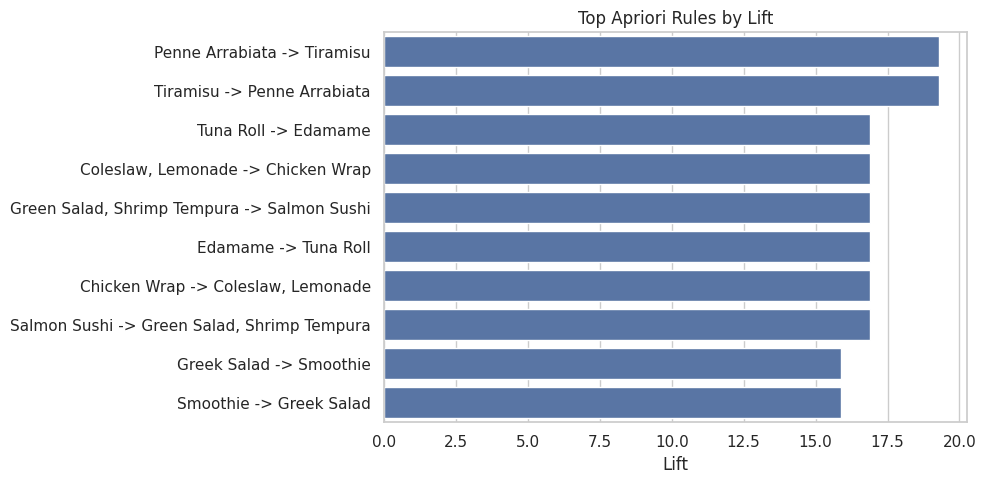

In [10]:
if not best_meal_combinations.empty:
    top_rules = best_meal_combinations.head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_rules, x="lift", y="rule")
    plt.title("Top Apriori Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No rules found. Try lowering support/confidence.")

In [11]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

## Inspect Transactions Data

In [12]:


print(" Number of Transactions:", len(transactions))
print(" Sample Transactions:\n")

for i in range(5):
    print(f"Order {i+1}: {transactions[i]}")

 Number of Transactions: 270
 Sample Transactions:

Order 1: ['Margherita Pizza', 'Pepsi']
Order 2: ['Caesar Salad', 'Pepperoni Pizza', 'Pepsi']
Order 3: ['Dumpling', 'Pad Thai']
Order 4: ['Edamame', 'Miso Soup', 'Tuna Roll']
Order 5: ['Chicken Wrap', 'Fries', 'Lemonade']


## Build Graph from Transactions

In [13]:

G = nx.Graph()

# Track edge creation count
edge_counter = 0

for idx, meals in enumerate(transactions):

    if len(meals) < 2:
        continue

    meal_pairs = list(combinations(meals, 2))

    for meal1, meal2 in meal_pairs:

        if G.has_edge(meal1, meal2):
            G[meal1][meal2]['weight'] += 1

        else:
            G.add_edge(meal1, meal2, weight=1)
            edge_counter += 1

print("✅ Graph Built Successfully\n")
print(" Total Nodes (Meals):", G.number_of_nodes())
print(" Total Edges (Connections):", G.number_of_edges())
print(" New Edges Created:", edge_counter)

✅ Graph Built Successfully

 Total Nodes (Meals): 46
 Total Edges (Connections): 110
 New Edges Created: 110


In [14]:
degrees = dict(G.degree())

degree_df = pd.DataFrame(
    list(degrees.items()),
    columns=["Meal", "Degree"]
).sort_values(by="Degree", ascending=False)

print(" Top Meals by Degree (Connections):\n")
display(degree_df.head(10))

 Top Meals by Degree (Connections):



,Meal,Degree
17,Coke,13
10,Fries,11
16,Garlic Bread,9
30,Onion Rings,7
11,Lemonade,6
7,Miso Soup,6
24,Shrimp Tempura,6
23,Salmon Sushi,6
6,Edamame,5
8,Tuna Roll,5


## Apply PageRank Algorithm

In [15]:


pagerank_scores = nx.pagerank(
    G,
    alpha=0.85,
    weight='weight'
)

print("✅ PageRank Computed Successfully")

✅ PageRank Computed Successfully


In [16]:


pagerank_df = pd.DataFrame(
    list(pagerank_scores.items()),
    columns=["Meal", "PageRank Score"]
)

pagerank_df = pagerank_df.sort_values(
    by="PageRank Score",
    ascending=False
)

print(" Top 10 Meals by PageRank:\n")
display(pagerank_df.head(10))

 Top 10 Meals by PageRank:



,Meal,PageRank Score
10,Fries,0.056060
17,Coke,0.053775
16,Garlic Bread,0.042251
1,Pepsi,0.035556
31,Jasmine Tea,0.031197
14,Guacamole,0.029818
2,Caesar Salad,0.028999
15,Horchata,0.028807
22,Green Salad,0.028008
11,Lemonade,0.027338


In [17]:


combined_df = pd.merge(
    pagerank_df,
    degree_df,
    on="Meal"
)

combined_df = combined_df.sort_values(
    by="PageRank Score",
    ascending=False
)

display(combined_df.head(10))

,Meal,PageRank Score,Degree
0,Fries,0.056060,11
1,Coke,0.053775,13
2,Garlic Bread,0.042251,9
3,Pepsi,0.035556,5
4,Jasmine Tea,0.031197,5
5,Guacamole,0.029818,5
6,Caesar Salad,0.028999,5
7,Horchata,0.028807,5
8,Green Salad,0.028008,4
9,Lemonade,0.027338,6


In [18]:


combined_df.to_csv("meal_graph_analysis.csv", index=False)

print(" File saved as 'meal_graph_analysis.csv'")

 File saved as 'meal_graph_analysis.csv'


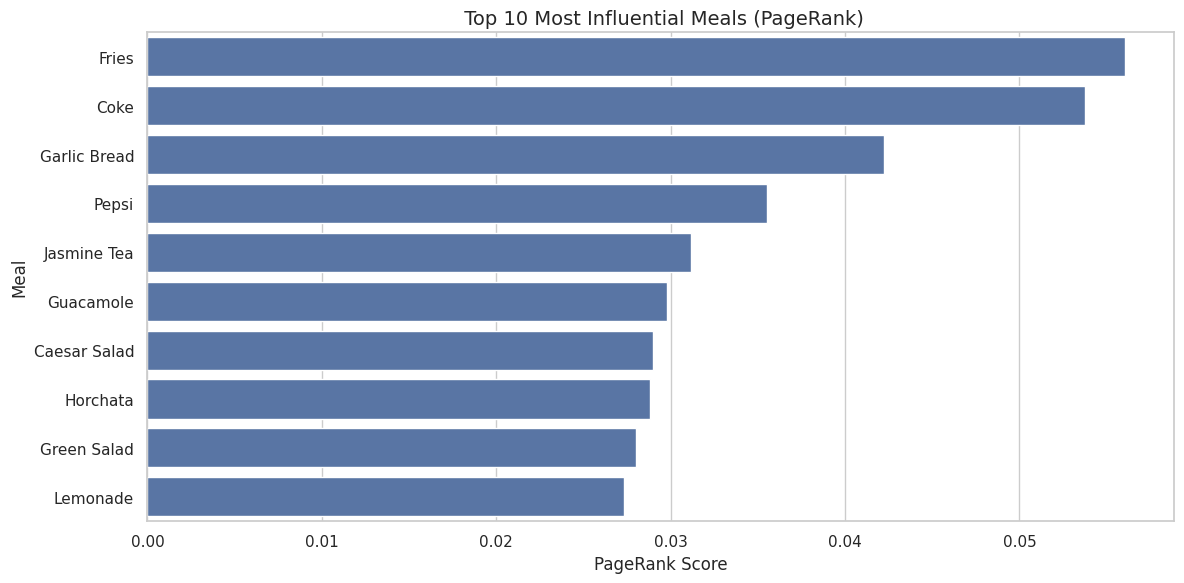

In [19]:

top_meals = combined_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_meals,
    x="PageRank Score",
    y="Meal"
)

plt.title(" Top 10 Most Influential Meals (PageRank)", fontsize=14)
plt.xlabel("PageRank Score")
plt.ylabel("Meal")

plt.tight_layout()
plt.show()

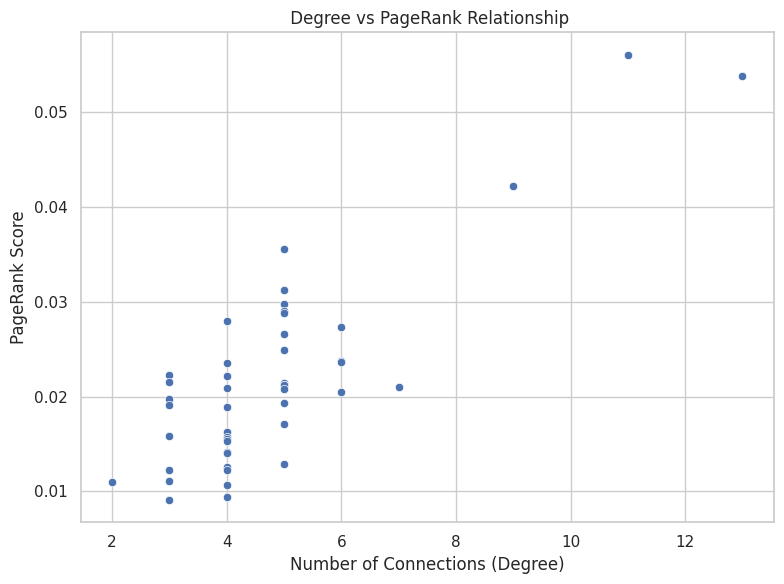

In [20]:


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=combined_df,
    x="Degree",
    y="PageRank Score"
)

plt.title(" Degree vs PageRank Relationship")
plt.xlabel("Number of Connections (Degree)")
plt.ylabel("PageRank Score")

plt.tight_layout()
plt.show()

# BERT Sentiment Analysis

🔹 Sentiment Analysis using BERT

In this step, we use a pre-trained BERT model to analyze the sentiment of customer reviews.

The model classifies each review into:
- POSITIVE
- NEGATIVE

### 🔹 Why are we doing this?
To convert unstructured text (reviews) into structured data (sentiment labels) that we can use in our recommendation system.

### 🔹 Output Explanation:
The output shows the first 10 reviews along with their predicted sentiment and confidence score.

Each result looks like:
- label → sentiment (POSITIVE / NEGATIVE)
- score → model confidence

This confirms that the model is working correctly on our dataset.

In [21]:
!pip install transformers torch

# Initialize BERT

In [22]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

# Take Sample of Sentiment Analysis

In [24]:
sample_df = clean_df.sample(200, random_state=42)

reviews = sample_df["review_text"].tolist()

results = classifier(reviews)

# عرض أول 10 نتائج
sample_df["bert_raw"] = results

sample_df[["review_text", "bert_raw"]].head(10)

,review_text,bert_raw
259,"Not happy at all, low quality and rude service.","{'label': 'NEGATIVE', 'score': 0.9997307658195..."
658,"Amazing flavors, perfectly seasoned. Five stars!","{'label': 'POSITIVE', 'score': 0.9998887777328..."
77,"Amazing flavors, perfectly seasoned. Five stars!","{'label': 'POSITIVE', 'score': 0.9998887777328..."
65,"Arrived on time, food was mediocre.","{'label': 'NEGATIVE', 'score': 0.9993952512741..."
81,"The worst delivery experience, food was inedible.","{'label': 'NEGATIVE', 'score': 0.9997174143791..."
223,"Disappointing quality, not worth the price at ...","{'label': 'NEGATIVE', 'score': 0.9998070597648..."
335,Overpriced for such average food quality.,"{'label': 'NEGATIVE', 'score': 0.9984201192855..."
264,"Loved every bite, the quality is consistently ...","{'label': 'POSITIVE', 'score': 0.9998793601989..."
515,Overpriced for such average food quality.,"{'label': 'NEGATIVE', 'score': 0.9984201192855..."
346,Superb quality! The meal was warm and delicious.,"{'label': 'POSITIVE', 'score': 0.9998862743377..."


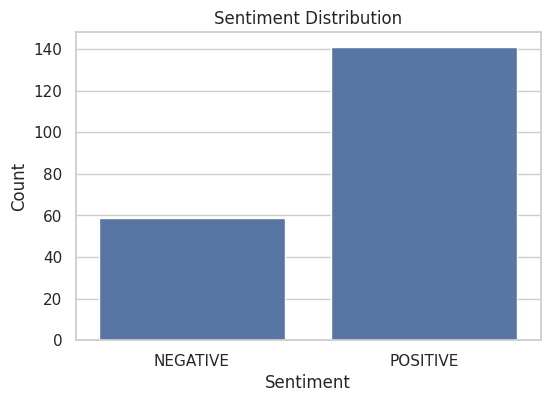

In [25]:
#Visualize
import matplotlib.pyplot as plt
import seaborn as sns

# استخراج الليبل
sample_df["label"] = [r["label"] for r in results]

plt.figure(figsize=(6,4))

sns.countplot(
    data=sample_df,
    x="label"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## 🔹 Sentiment Count (Bar Chart)

This step displays the number of reviews for each sentiment using a bar chart.

### 🔹 Why are we doing this?
To see the exact count of:
- Positive reviews
- Negative reviews

This is more precise than percentages.

### 🔹 Output Explanation:
Each bar represents the number of reviews in that category.

Higher bars = more frequent sentiment.

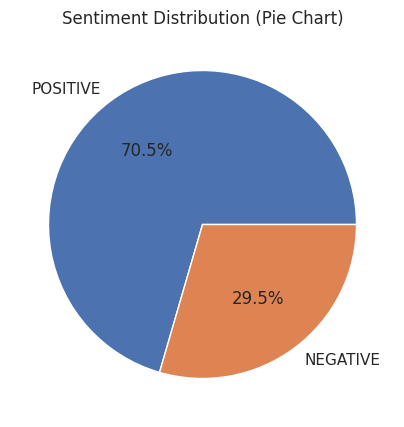

In [31]:
sentiment_counts = sample_df["label"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution (Pie Chart)")
plt.show()


# Convert to 3 Classes

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
#first 5 coloumns
print(sample_df["bert_sentiment"].head())

#no of sentiments
counts = sample_df["bert_sentiment"].value_counts()

print(counts)

259    negative
658    positive
77     positive
65     negative
81     negative
Name: bert_sentiment, dtype: object
bert_sentiment
positive    141
negative     59
Name: count, dtype: int64


## 🔹 Inspecting Sentiment Results

In this step, we print:
1. The first 5 sentiment results
2. The total count of each sentiment

###🔹 Why are we doing this?
To validate that:
- The sentiment conversion is correct
- The distribution makes sense

### 🔹 Output Explanation:
- The first output shows sample labels (positive / negative / neutral)
- The second output shows total counts

This helps verify data quality before moving forward.

# Compute Sentiment Score

In [40]:
sentiment_score = sample_df.groupby("meal_name")["bert_sentiment"].value_counts().unstack().fillna(0)

sentiment_score["total"] = sentiment_score.sum(axis=1)

sentiment_score["score"] = (
    sentiment_score.get("positive", 0) - sentiment_score.get("negative", 0)
) / sentiment_score["total"]

sentiment_score = sentiment_score.reset_index()
print(sentiment_score)

bert_sentiment            meal_name  negative  positive  total     score
0                     Avocado Toast       3.0       0.0    3.0 -1.000000
1                 BBQ Chicken Pizza       1.0       2.0    3.0  0.333333
2                         Beef Taco       0.0       5.0    5.0  1.000000
3                         Beef Wrap       1.0       3.0    4.0  0.500000
4                            Burger       0.0       1.0    1.0  1.000000
5                      Caesar Salad       3.0       2.0    5.0 -0.200000
6                      Chicken Taco       1.0       1.0    2.0  0.000000
7                      Chicken Wrap       2.0       4.0    6.0  0.333333
8                              Coke       3.0       4.0    7.0  0.142857
9                          Coleslaw       0.0       5.0    5.0  1.000000
10                    Double Burger       1.0       5.0    6.0  0.666667
11                      Dragon Roll       0.0       3.0    3.0  1.000000
12                         Dumpling       0.0      

In [44]:
pagerank_df = pd.read_csv("meal_graph_analysis.csv")
rules_df = pd.read_csv("best_meal_combinations.csv")
pagerank_df.head()
rules_df.head()

,rule,support,confidence,lift
0,Penne Arrabiata -> Tiramisu,0.0333,0.6429,19.2857
1,Tiramisu -> Penne Arrabiata,0.0333,1.0000,19.2857
2,Tuna Roll -> Edamame,0.0481,1.0000,16.8750
3,"Coleslaw, Lemonade -> Chicken Wrap",0.0407,1.0000,16.8750
4,"Green Salad, Shrimp Tempura -> Salmon Sushi",0.0407,1.0000,16.8750


In [45]:
rules_df["score"] = rules_df["lift"] * rules_df["confidence"]

comb_score = rules_df[["rule", "score"]]
comb_score

,rule,score
0,Penne Arrabiata -> Tiramisu,12.398777
1,Tiramisu -> Penne Arrabiata,19.285700
2,Tuna Roll -> Edamame,16.875000
3,"Coleslaw, Lemonade -> Chicken Wrap",16.875000
4,"Green Salad, Shrimp Tempura -> Salmon Sushi",16.875000
...,...,...
70,Garlic Bread -> Pepsi,2.663747
71,Coke -> Fries,1.850529
72,Fries -> Coke,1.506260
73,Garlic Bread -> Coke,0.650156


## 🔹 Calculating Meal Combination Strength

We compute a score for each meal combination:

Score = Lift × Confidence

### ✅ Why are we doing this?
To identify strong relationships between meals.

- Lift → strength of association
- Confidence → probability of co-occurrence

### 📊 Output Explanation:
The table shows:
- Meal combinations (rules)
- Their strength score

Higher score = stronger relationship between meals.

# Merge with PageRank

In [46]:
final_df = pd.merge(
    pagerank_df,
    sentiment_score,
    left_on="Meal",
    right_on="meal_name",
    how="left"
)
#Fix Missing Values
num_cols = ["PageRank Score", "score", "Degree"]
final_df[num_cols] = final_df[num_cols].fillna(0)

# Final Score Calculation
final_df["final_score"] = (
    0.4 * final_df["PageRank Score"] +
    0.3 * final_df["score"] +
    0.3 * final_df["Degree"]
)

final_df = final_df.sort_values(by="final_score", ascending=False)
final_df.head(10)


,Meal,PageRank Score,Degree,meal_name,negative,positive,total,score,final_score
1,Coke,0.053775,13,Coke,3.0,4.0,7.0,0.142857,3.964367
0,Fries,0.056060,11,Fries,1.0,11.0,12.0,0.833333,3.572424
2,Garlic Bread,0.042251,9,Garlic Bread,5.0,5.0,10.0,0.000000,2.716900
21,Onion Rings,0.021005,7,Onion Rings,2.0,5.0,7.0,0.428571,2.236973
24,Shrimp Tempura,0.020439,6,Shrimp Tempura,0.0,3.0,3.0,1.000000,2.108175
9,Lemonade,0.027338,6,Lemonade,1.0,2.0,3.0,0.333333,1.910935
4,Jasmine Tea,0.031197,5,Jasmine Tea,0.0,8.0,8.0,1.000000,1.812479
10,Spring Rolls,0.026588,5,Spring Rolls,0.0,1.0,1.0,1.000000,1.810635
11,Edamame,0.024955,5,Edamame,0.0,2.0,2.0,1.000000,1.809982
19,Dumpling,0.021276,5,Dumpling,0.0,2.0,2.0,1.000000,1.808511


## 🔹 Final Recommendation Model

We combine all factors into a single score:
- PageRank (popularity)
- Sentiment Score (user opinion)
- Degree (connectivity)

### 🧮 Formula:
Final Score =
0.4 × PageRank +
0.3 × Sentiment +
0.3 × Degree

### ✅ Why are we doing this?
To create a balanced recommendation system that considers:
- What people like
- What is popular
- What is frequently connected

### 📊 Output Explanation:
Each meal gets a final score.

Higher score = better recommendation.

# Top Recommendations

In [47]:
top_recommendations = final_df.head(10)

display(top_recommendations)

,Meal,PageRank Score,Degree,meal_name,negative,positive,total,score,final_score
1,Coke,0.053775,13,Coke,3.0,4.0,7.0,0.142857,3.964367
0,Fries,0.056060,11,Fries,1.0,11.0,12.0,0.833333,3.572424
2,Garlic Bread,0.042251,9,Garlic Bread,5.0,5.0,10.0,0.000000,2.716900
21,Onion Rings,0.021005,7,Onion Rings,2.0,5.0,7.0,0.428571,2.236973
24,Shrimp Tempura,0.020439,6,Shrimp Tempura,0.0,3.0,3.0,1.000000,2.108175
9,Lemonade,0.027338,6,Lemonade,1.0,2.0,3.0,0.333333,1.910935
4,Jasmine Tea,0.031197,5,Jasmine Tea,0.0,8.0,8.0,1.000000,1.812479
10,Spring Rolls,0.026588,5,Spring Rolls,0.0,1.0,1.0,1.000000,1.810635
11,Edamame,0.024955,5,Edamame,0.0,2.0,2.0,1.000000,1.809982
19,Dumpling,0.021276,5,Dumpling,0.0,2.0,2.0,1.000000,1.808511


## 🔹 Top Recommended Meals

We select the top 10 meals based on the final score.

### ✅ Why are we doing this?
To provide the best meal recommendations to users.

### 📊 Output Explanation:
The table shows the top-ranked meals sorted by their final score.

The first meal is the most recommended.

# Visualization

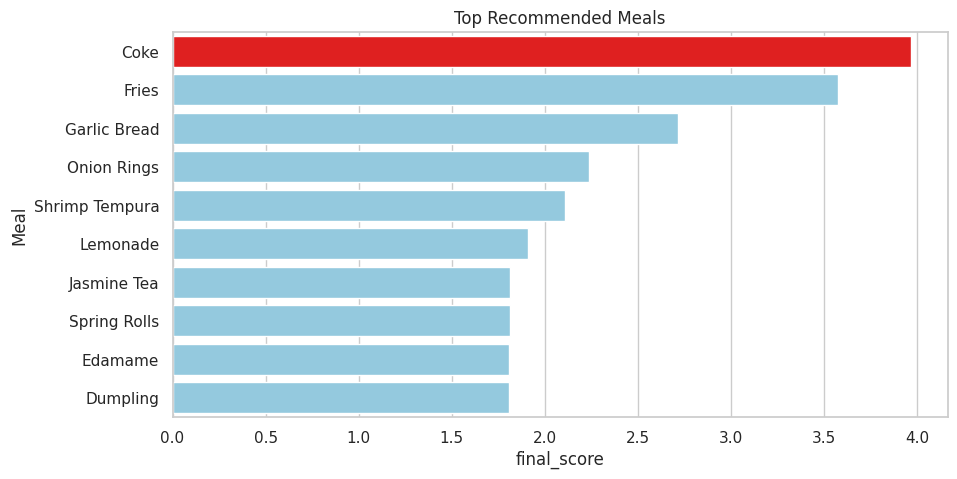

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

# إنشاء قائمة ألوان
colors = ["red"] + ["skyblue"] * (len(top_recommendations) - 1)

sns.barplot(
    data=top_recommendations,
    x="final_score",
    y="Meal",
    palette=colors
)

plt.title("Top Recommended Meals")
plt.show()

## 🔹 Visualizing Top Recommendations

This step displays the top 10 meals using a bar chart.

### ✅ Why are we doing this?
To present the results in a clear and visual way.

### 📊 Output Explanation:
- Each bar represents a meal
- The length of the bar = final score
- The top meal is highlighted in a different color

This makes it easy to identify the best recommendation.

In [49]:
final_df.to_csv("final_recommendations.csv", index=False)